In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import csv
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})

NAVY = '#1B3A6B'
ACCENT = '#2C6BAD'
ORANGE = '#D35400'
GREEN = '#1A7A4E'
GRAY = '#6B7280'

print('Libraries loaded successfully.')

C:\Users\jaden\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\jaden\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded successfully.


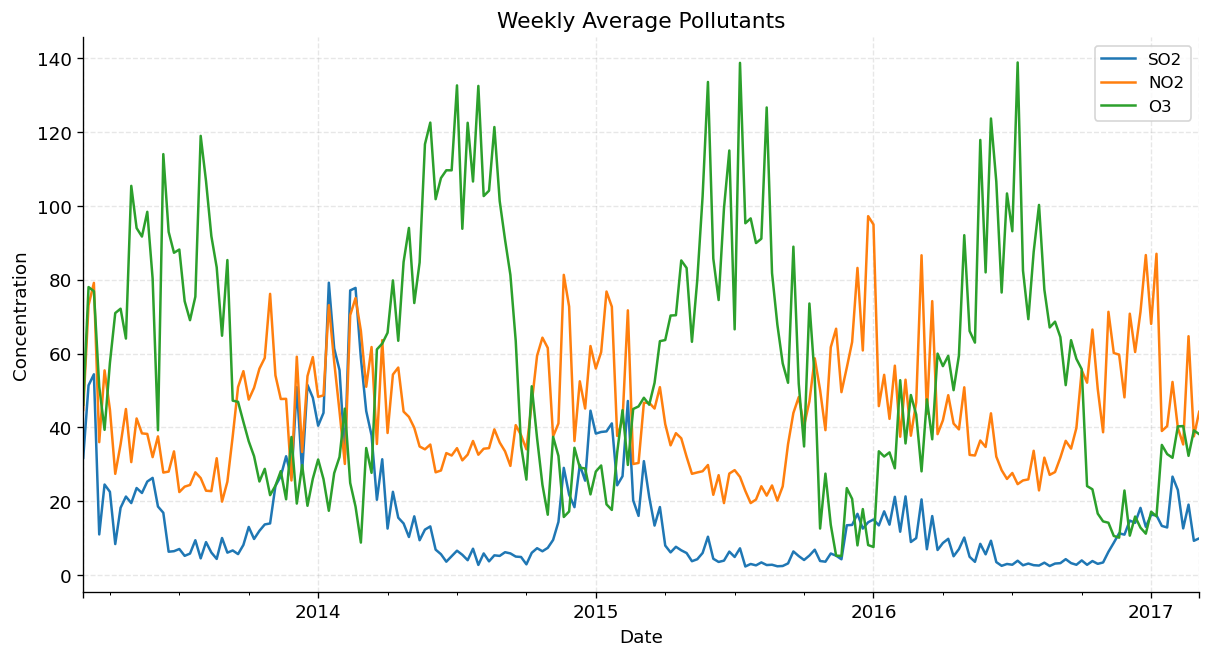

<Axes: xlabel='datetime'>

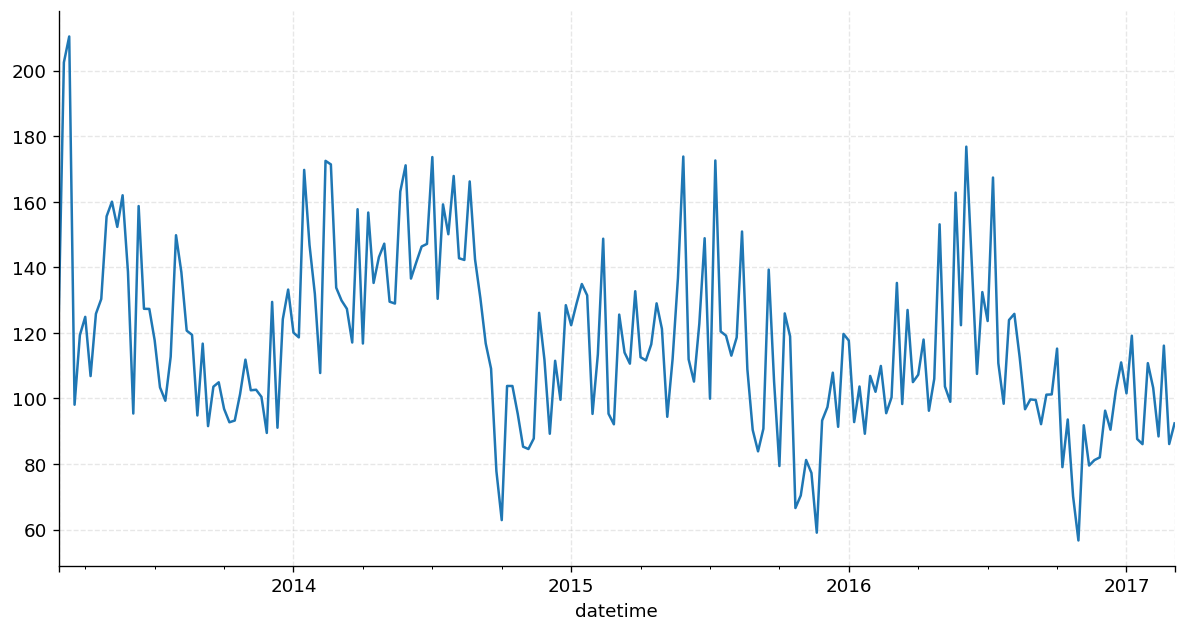

In [2]:
# Load the data and graph it
# Source: https://archive.ics.uci.edu/dataset/501/beijing+multi+site+air+quality+data
data = pd.read_csv("Changping_pollution.csv")

data['datetime'] = pd.to_datetime(data[['year', 'month', 'day', 'hour']])
data = data.set_index('datetime')
data = data.sort_index()

# Keep only pollutant columns
data = data[['SO2', 'NO2', 'O3']]

# Aggregate the data to get a cleaner data set
data_weekly = data.resample('W').mean()

# Separate the data into specific pollutants 
P1 = data_weekly['SO2']
P2 = data_weekly['NO2']
P3 = data_weekly['O3']

data_weekly.plot(figsize=(12,6))
plt.title("Weekly Average Pollutants")
plt.xlabel("Date")
plt.ylabel("Concentration")
plt.grid(True)
plt.show()

data_weekly['P'] = data_weekly['SO2'] + data_weekly['NO2'] + data_weekly['O3']
P = data_weekly['P']

P.plot(figsize = (12,6))

For each of the series plotted above, they all appear to have a seasonality component, but no noticeable trend. This will mean that out of each of the exponential smoothing models studied, the Holt-Winters method will be the best fit for modeling each of them.

In [3]:
# Train-test split
split = round(len(data_weekly['SO2']) * 0.8)
train = data_weekly.iloc[:split]
test = data_weekly.iloc[split:]

# Bottom up approach for pollutants
forecast_total = np.zeros(len(test))
results = []

for col in train.columns[:3]:
    model = ExponentialSmoothing(train[col], trend=None, seasonal='add', seasonal_periods=52).fit()
    forecast = model.forecast(len(test))
    forecast_total += forecast
    
    # Compute the mean absolute error at the product level
    mae = np.mean(np.abs(test[col].values - forecast.values))

    # Compute the mean absolute percentage error at the product level
    wmape = np.sum(np.abs(test[col].values - forecast.values)) / np.sum(test[col].values)

    results.append({
        "Pollutant": col,
        "MAE (Bottom up)": mae,
        "wMAPE (Bottom up)": wmape
    })
    
# Compute the mean absolute error at the category level
mae_total = np.mean(np.abs(P.iloc[split:].values - forecast_total))

# Compute the mean absolute percentage error at the category level
wmape_total = np.sum(np.abs(P.iloc[split:].values - forecast_total)) / np.sum(P.iloc[split:].values)

results_df = pd.DataFrame(results)
results_df = pd.concat([
    results_df,
    pd.DataFrame([{
        "Pollutant": "TOTAL POLLUTANTS",
        "MAE (Bottom up)": mae_total,
        "wMAPE (Bottom up)": wmape_total
    }])
], ignore_index=True)
print(results_df)

          Pollutant  MAE (Bottom up)  wMAPE (Bottom up)
0               SO2         6.925581           0.838565
1               NO2         9.192489           0.204100
2                O3        11.460247           0.218891
3  TOTAL POLLUTANTS        15.547044           0.147151


In [4]:
# Use top down (PHA) method to model the pollutants
# Compute pha = Y_i / S
pha = {}

for col in train.columns[:3]:
    pha[col] = train[col].values.mean() / P.iloc[:split].values.mean()
    
model_category = ExponentialSmoothing(P.iloc[:split].values, trend = None, seasonal='add', seasonal_periods=52).fit()
forecast_category = model_category.forecast(len(test))

mae_category = np.mean(np.abs(P.iloc[split:].values - forecast_category))
wmape_category = np.sum(np.abs(P.iloc[split:].values - forecast_category)) / np.sum(P.iloc[split:].values)

# Disaggregate to the product level
pollutants_forecast = pd.DataFrame(index=test.index)
for col in train.columns[:3]:
    pollutants_forecast[col] = pha[col] * forecast_category
    
results_td = []

for col in train.columns[:3]:
    mae = np.mean(np.abs(test[col].values - pollutants_forecast[col]))
    wmape = np.sum(np.abs(test[col].values - pollutants_forecast[col])) / np.sum(test[col].values)

    results_td.append({
        "Pollutant": col,
        "MAE": mae,
        "wMAPE": wmape,
        "Level": "Pollutant (Top-Down)"
    })
    
results_td.append({
    "Pollutant": "CATEGORY",
    "MAE": mae_category,
    "wMAPE": wmape_category,
    "Level": "Category (Top-Down)"
})

# Convert to DataFrame
results_td_df = pd.DataFrame(results_td)

# Round metrics for readability
results_td_df["MAE"] = results_td_df["MAE"].round(2)
results_td_df["wMAPE"] = (results_td_df["wMAPE"]).round(3)

# Sort
results_td_df = results_td_df.sort_values(by="wMAPE", ascending=False)

# Display
display(results_td_df)

,Pollutant,MAE,wMAPE,Level
0,SO2,7.87,0.952,Pollutant (Top-Down)
2,O3,27.70,0.529,Pollutant (Top-Down)
1,NO2,18.33,0.407,Pollutant (Top-Down)
3,CATEGORY,15.68,0.148,Category (Top-Down)


The bottom up and top down approaches were compared, and even though both methods have relatively high weighted mean absolute percentage error values, the values from the bottom up method were lower, so it is the clear winner of this comparison.

            Series  ADF statistic  p value  Used lags  Critical value 5%  \
0  Pollution Total         -2.993   0.0355          4             -2.876   

  Decision at 5%  
0     Stationary  


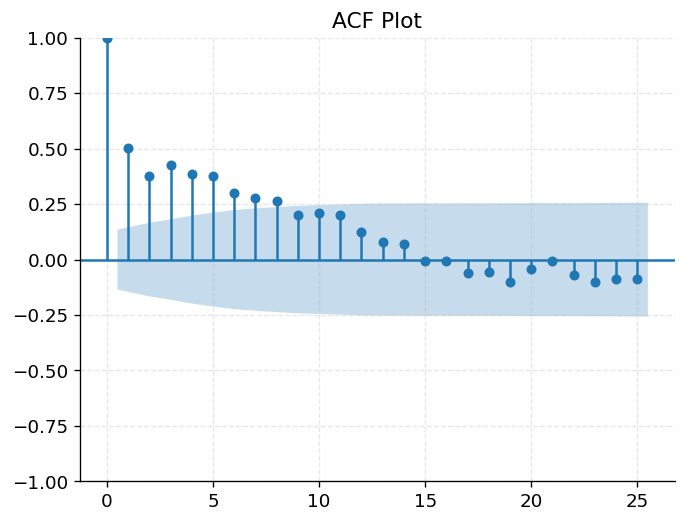

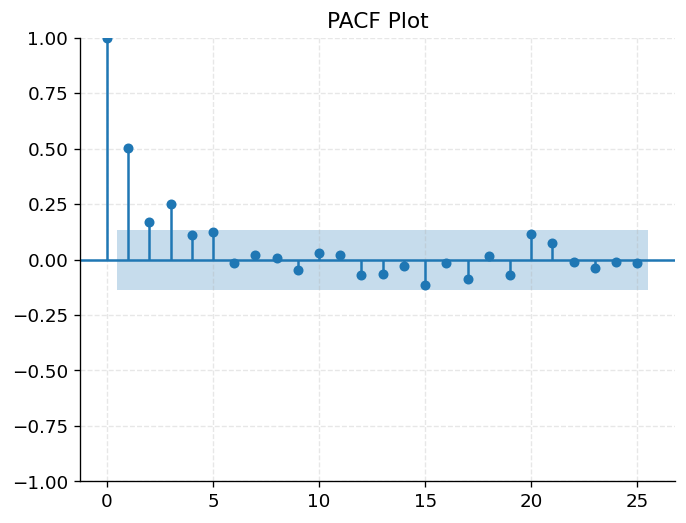

In [5]:
# Determine the stationarity of each series
def adf_table(series, name):
    stat, pvalue, used_lag, nobs, crit_vals, *_ = adfuller(np.asarray(series).astype(float), autolag='AIC')
    return pd.DataFrame({
        'Series': [name],
        'ADF statistic': [round(stat, 3)],
        'p value': [round(pvalue, 4)],
        'Used lags': [used_lag],
        'Critical value 5%': [round(crit_vals['5%'], 3)],
        'Decision at 5%': ['Stationary' if pvalue < 0.05 else 'Not stationary'],
    })

print(adf_table(P,"Pollution Total"))

# Plot the ACF and PACF for the series
plot_acf(P, lags=25)
plt.title("ACF Plot")
plt.show()

plot_pacf(P, lags=25)
plt.title("PACF Plot")
plt.show()

The plot of the ACF function appears to tail off, while the plot of the PACF function cuts off at lag 3, so the ARIMA orders of AR(1), AR(2), and AR(3) will be tested.

In [35]:
# Fit the candidate models
orders = [(1,0,0), (2,0,0), (3,0,0)]
model_names = ["AR(1)", "AR(2)", "AR(3)"]

results_list = []

for name, order in zip(model_names, orders):
    
    # Fit model
    model = ARIMA(P, order=order).fit()
    
    # Ljung-Box test
    lb_test = acorr_ljungbox(model.resid, lags=[10], return_df=True)
    lb_pvalue = lb_test["lb_pvalue"].iloc[0]
    
    # Store results
    results_list.append({
        "Model": name,
        "Order": order,
        "AIC": model.aic,
        "BIC": model.bic,
        "Ljung-Box p-value": lb_pvalue
    })

# Create table
results_df = pd.DataFrame(results_list)

print(results_df)

   Model      Order          AIC          BIC  Ljung-Box p-value
0  AR(1)  (1, 0, 0)  1919.108378  1929.149701           0.003245
1  AR(2)  (2, 0, 0)  1914.314153  1927.702583           0.053675
2  AR(3)  (3, 0, 0)  1899.721683  1916.457220           0.723833


The AR(1) model was the only model with a Ljung-Box p-value less than 5%, so it will be used for modeling from this family of models.

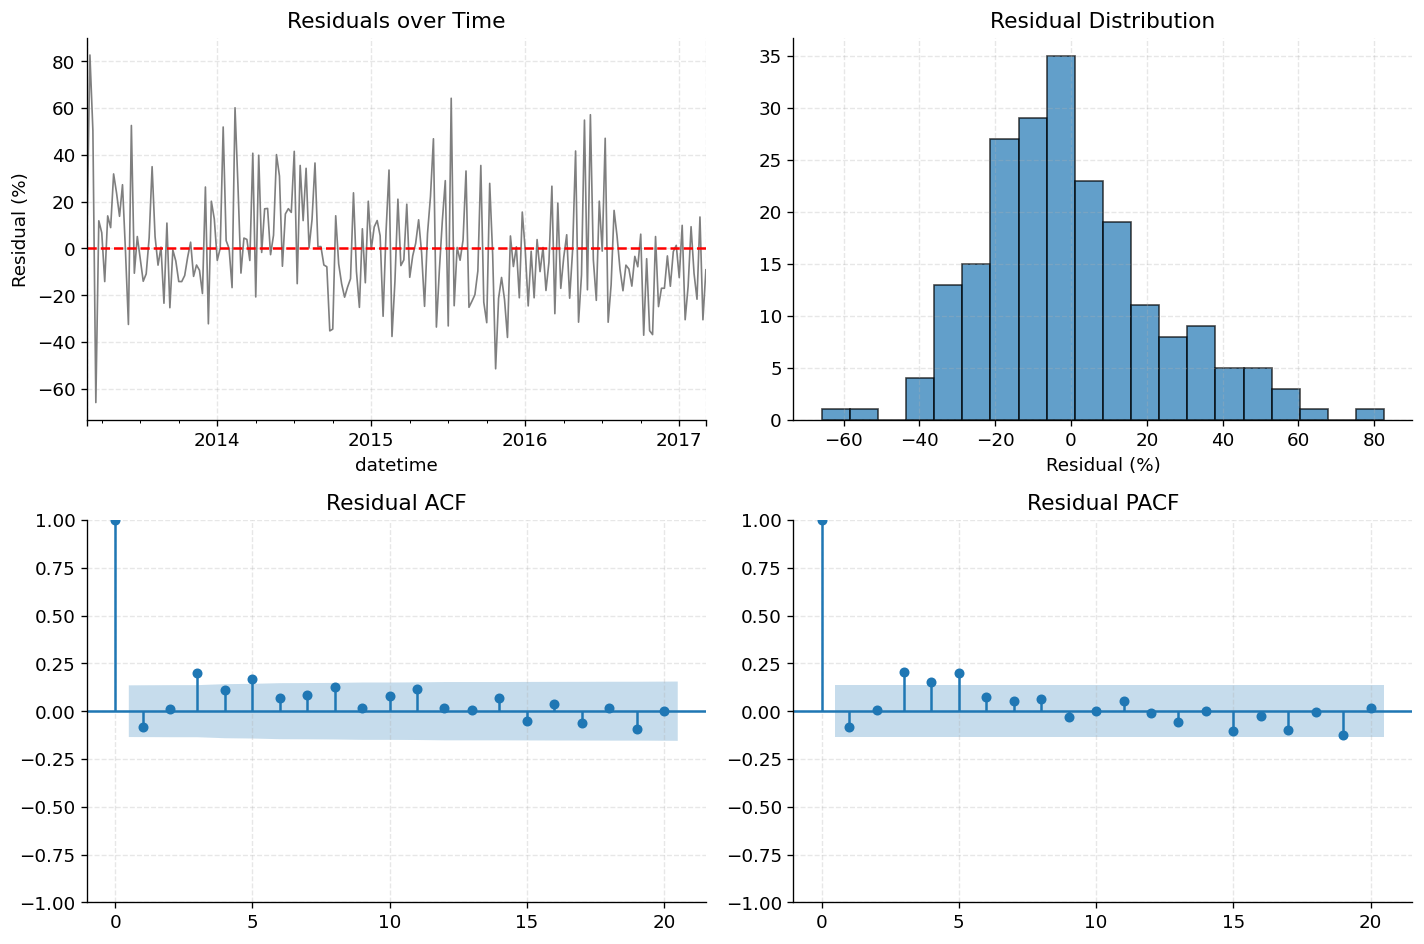

,Lag,Q Statistic,p-value
0,10,26.3937,0.0032
1,15,31.1563,0.0084
2,20,34.5500,0.0226


In [37]:
# Analyze the residuals of the AR(1) model
ar_model_1 = ARIMA(P, order=(1,0,0)).fit()
ar_resid_1 = ar_model_1.resid

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
ar_resid_1.plot(ax=axes[0, 0], color='tab:gray', linewidth=1)
axes[0, 0].axhline(0, color='red', ls='--')
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_ylabel('Residual (%)')

axes[0, 1].hist(ar_resid_1, bins=20, edgecolor='black', alpha=0.7, color='tab:blue')
axes[0, 1].set_title('Residual Distribution')
axes[0, 1].set_xlabel('Residual (%)')

plot_acf(ar_resid_1, lags=20, ax=axes[1, 0])
axes[1, 0].set_title('Residual ACF')
plot_pacf(ar_resid_1, lags=20, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title('Residual PACF')
plt.tight_layout(); plt.show()

lb_ar_1 = acorr_ljungbox(ar_resid_1, lags=[10, 15, 20], return_df=True)
lb_ar_1 = lb_ar_1.reset_index().rename(columns={
    'index': 'Lag', 'lb_stat': 'Q Statistic', 'lb_pvalue': 'p-value'})
display(lb_ar_1.round(4))

The residuals studied do not appear to have any clear patterns, and the Ljung-Box p-values were all less than 5%, so the AR(1) model seems adequate to forecast the series. 

In [9]:
# Analyze the tree based models 
df = data_weekly.copy()

# Create lag features
df["TOTAL"] = df.iloc[:, :3].sum(axis=1)
target = "TOTAL"

df["TOTAL_lag1"] = df["TOTAL"].shift(1)
df["TOTAL_lag2"] = df["TOTAL"].shift(2)
df["TOTAL_lag3"] = df["TOTAL"].shift(3)
df["TOTAL_lag4"] = df["TOTAL"].shift(4)
df["TOTAL_lag5"] = df["TOTAL"].shift(5)

# Time features
df["week"] = np.arange(len(df))
df["month"] = df.index.month if hasattr(df.index, "month") else 0

# Drop NA values
df = df.dropna()

# Train test split
split = round(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

features = [col for col in df.columns if "lag" in col] + ["week"]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

# Define baseline naive model
y_pred_naive = test[f"{target}_lag1"].values

# Define decision tree model
tree = DecisionTreeRegressor(random_state=0)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

# Define random forest model
rf = RandomForestRegressor(n_estimators=200, random_state=0)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Compute error metrics
def compute_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
    return mae, rmse, wmape

results = []

for name, pred in [
    ("Naive", y_pred_naive),
    ("Decision Tree", y_pred_tree),
    ("Random Forest", y_pred_rf)
]:
    mae, rmse, wmape = compute_metrics(y_test.values, pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "wMAPE": wmape
    })

results_df = pd.DataFrame(results)
print(results_df)

           Model        MAE       RMSE     wMAPE
0          Naive  18.302094  23.422511  0.175543
1  Decision Tree  29.161696  38.094466  0.279701
2  Random Forest  18.369553  23.801099  0.176190
